In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# 1. Hyperparameters
batch_size = 64
epochs = 5
input_shape = (32, 32, 3)
# MobileNetV2 prefers larger inputs, so we will resize inside the model
resized_shape = (96, 96, 3)

In [3]:
# 2. Load and Prepare Data
print("Downloading and preparing CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


d:\Internship\Alfido Task - 2\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
# 3. Data Augmentation Pipeline
# Building this into the model ensures it only runs during training (on the GPU if available)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

In [6]:
# 4. Load Pretrained Model (Transfer Learning)
print("Loading pretrained MobileNetV2...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=resized_shape,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model to only train the new classification head
base_model.trainable = False

Loading pretrained MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
# 5. Build the Final Model
inputs = tf.keras.Input(shape=input_shape)
# Apply augmentation
x = data_augmentation(inputs)
# Resize to fit MobileNetV2's minimum optimal size
x = tf.keras.layers.Resizing(96, 96)(x)
# MobileNetV2 specific preprocessing (scales pixels between -1 and 1)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
# Pass through base model
x = base_model(x, training=False)
# Convert features to a single vector per image
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# Add dropout for regularization
x = tf.keras.layers.Dropout(0.2)(x)
# Final output layer
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
# 6. Compile and Train
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
print("Starting training...")
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_data=(x_test, y_test),
    batch_size=batch_size
)

Starting training...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 113ms/step - accuracy: 0.6081 - loss: 1.1415 - val_accuracy: 0.7893 - val_loss: 0.6102
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.6786 - loss: 0.9223 - val_accuracy: 0.8123 - val_loss: 0.5511
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.6924 - loss: 0.8941 - val_accuracy: 0.8200 - val_loss: 0.5234
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 109ms/step - accuracy: 0.6930 - loss: 0.8842 - val_accuracy: 0.8131 - val_loss: 0.5485
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.6944 - loss: 0.8801 - val_accuracy: 0.8181 - val_loss: 0.5315


In [10]:
# 7. Evaluate Metrics
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")


Evaluating on test data...
313/313 - 16s - 51ms/step - accuracy: 0.8181 - loss: 0.5315
Final Test Accuracy: 81.81%


In [11]:
# 8. Save the Model
save_path = 'cifar10_mobilenetv2.keras'
model.save(save_path)
print(f"Model saved to {save_path}")

Model saved to cifar10_mobilenetv2.keras


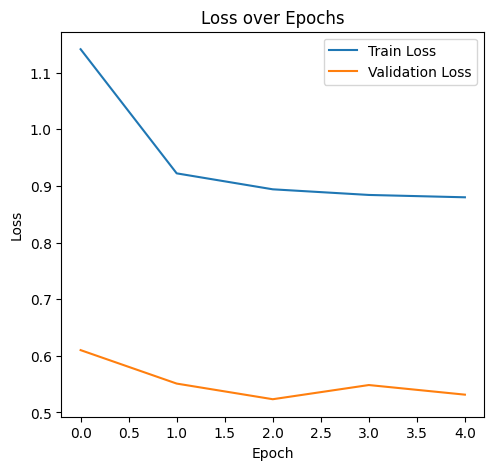

In [12]:
# 9. Plotting Training Curves
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Training curves saved to 'training_curves.png'.


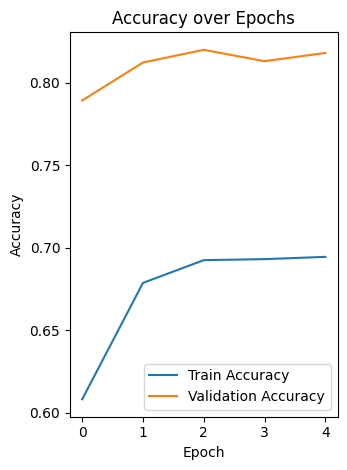

In [13]:
# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
print("Training curves saved to 'training_curves.png'.")
plt.show()